In [1]:
from pyspark.sql import SparkSession

spark = (
        SparkSession.builder
        .appName("fintek_analytics")
        .master("spark://spark-master:7077")

        .config("spark.executor.memory", "4g")
        .config("spark.driver.memory", "1g")
        .config("spark.executor.cores", 4)
        .config("spark.sql.shuffle.partitions", 10)

        .config("spark.driver.host", "fintek-jupyter")
        .config("spark.driver.bindAddress", "0.0.0.0")

        .config("spark.jars.packages", "org.postgresql:postgresql:42.7.3")
        .config("spark.sql.autoBroadcastJoinThreshold", "-1")

        .getOrCreate()
    )

:: loading settings :: url = jar:file:/opt/conda/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/rapids/.ivy2.5.2/cache
The jars for the packages stored in: /home/rapids/.ivy2.5.2/jars
org.postgresql#postgresql added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-0da6acac-e6e4-4446-a0a4-d3c37dfaef04;1.0
	confs: [default]
	found org.postgresql#postgresql;42.7.3 in central
	found org.checkerframework#checker-qual;3.42.0 in central
downloading https://repo1.maven.org/maven2/org/postgresql/postgresql/42.7.3/postgresql-42.7.3.jar ...
	[SUCCESSFUL ] org.postgresql#postgresql;42.7.3!postgresql.jar (136ms)
downloading https://repo1.maven.org/maven2/org/checkerframework/checker-qual/3.42.0/checker-qual-3.42.0.jar ...
	[SUCCESSFUL ] org.checkerframework#checker-qual;3.42.0!checker-qual.jar (56ms)
:: resolution report :: resolve 696ms :: artifacts dl 195ms
	:: modules in use:
	

In [2]:
jdbc_url = "jdbc:postgresql://fintek-postgres:5432/fintek_db"

properties = {
    "user": "finance",
    "password": "finance123",
    "driver": "org.postgresql.Driver"
}

try:
    print("Veriler veritabanından okunuyor...")
    
    sql_returns = spark.read.jdbc(
    url=jdbc_url,
    table="""
    (   SELECT
            a.ticker,
            r.return_time,
            r.log_return,
            a.asset_type
        FROM returns r
        JOIN assets a
            ON r.asset_id = a.asset_id
        WHERE r.return_time >= '2020-01-01'
    ) AS index_returns
    """,
    properties=properties
)

    sql_prices = spark.read.jdbc(
    url=jdbc_url,
    table="""
    (   SELECT
            a.ticker,
            a.asset_type,
            p.*
        FROM prices p
        JOIN assets a
            ON p.asset_id = a.asset_id
        WHERE p.price_time >= '2020-01-01'
    ) AS index_prices
    """,
    properties=properties
)
    print("\n--- Returns ---")
    sql_returns.show(5)
    
    print("\n--- Prices ---")
    sql_prices.show(5)

except Exception as e:
    print(f"Veritabanına bağlanırken bir hata oluştu: {e}")

Veriler veritabanından okunuyor...

--- Returns ---


+------+-----------+--------------------+----------+
|ticker|return_time|          log_return|asset_type|
+------+-----------+--------------------+----------+
|  AAPL| 2020-01-03|-0.00976960241858...|    equity|
|  MSFT| 2020-01-03|-0.01253022392556...|    equity|
|  NVDA| 2020-01-03|-0.01613520668915829|    equity|
|  AMZN| 2020-01-03|-0.01221331447267...|    equity|
| GOOGL| 2020-01-03|-0.00524503532968...|    equity|
+------+-----------+--------------------+----------+
only showing top 5 rows

--- Prices ---
+------+----------+--------+--------+----------+------------------+-----------------+------------------+------------------+---------+
|ticker|asset_type|price_id|asset_id|price_time|              open|             high|               low|             close|   volume|
+------+----------+--------+--------+----------+------------------+-----------------+------------------+------------------+---------+
|  AAPL|    equity|       1|       1|2020-01-02| 71.40977771923563|72.46077614730

In [3]:
from pyspark.sql.functions import col
returns_stocks = sql_returns.filter(
    col("asset_type") == "equity"
).select(
    col("ticker"),
    col("return_time").alias("date"),
    col("log_return").alias("return")
)

returns_indices = sql_returns.filter(
    col("asset_type") == "index"
).select(
    col("ticker"),
    col("return_time").alias("date"),
    col("log_return").alias("return")
)

returns_stocks.show(5)
returns_indices.show(5)

+------+----------+--------------------+
|ticker|      date|              return|
+------+----------+--------------------+
|  AAPL|2020-01-03|-0.00976960241858...|
|  AAPL|2020-01-06|0.007936565578592389|
|  AAPL|2020-01-07|-0.00471385719555...|
|  AAPL|2020-01-08|0.015958109525148405|
|  AAPL|2020-01-09| 0.02101852692153685|
+------+----------+--------------------+
only showing top 5 rows
+------+----------+--------------------+
|ticker|      date|              return|
+------+----------+--------------------+
| SP500|2020-01-03|-0.00708490936495...|
| SP500|2020-01-06|0.003527145194272564|
| SP500|2020-01-07|-0.00280717508459...|
| SP500|2020-01-08|0.004890473485641129|
| SP500|2020-01-09|0.006633214116906491|
+------+----------+--------------------+
only showing top 5 rows


In [4]:
from pyspark.sql.functions import col

prices_stocks = sql_prices.filter(
    col("asset_type") == "equity"
).select(
    col("ticker"),
    col("price_time").alias("date"),
    col("open"),
    col("high"),
    col("low"),
    col("close"),
    col("volume")
)

prices_indices = sql_prices.filter(
    col("asset_type") == "index"
).select(
    col("ticker"),
    col("price_time").alias("date"),
    col("open"),
    col("high"),
    col("low"),
    col("close"),
    col("volume")
)

prices_stocks.show(5)
prices_indices.show(5)

+------+----------+-----------------+-----------------+-----------------+-----------------+---------+
|ticker|      date|             open|             high|              low|            close|   volume|
+------+----------+-----------------+-----------------+-----------------+-----------------+---------+
|  AAPL|2020-01-02|71.40977771923563|72.46077614730521|71.15667416341765| 72.4005126953125|135480400|
|  AAPL|2020-01-03| 71.6291376132339|72.45595040957373|71.47245410922795| 71.6966323852539|146322800|
|  AAPL|2020-01-06| 70.8191932093111|  72.306490935931|70.56849521434884| 72.2679214477539|118387200|
|  AAPL|2020-01-07|72.27758611058375|72.53310260522755|71.70870255084994|71.92806243896484|108872000|
|  AAPL|2020-01-08|71.63155170295238|73.38642316119072|71.63155170295238| 73.0851058959961|132079200|
+------+----------+-----------------+-----------------+-----------------+-----------------+---------+
only showing top 5 rows
+------+----------+-----------------+-----------------+---

In [5]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# ----------------------------------
# 1) WINDOW (KRİTİK)
# ----------------------------------
w = Window.partitionBy("ticker").orderBy("date")

# ----------------------------------
# 2) PRICE DATA (zaten prices_stocks var)
# ----------------------------------
df_feat = prices_stocks

# ----------------------------------
# 3) HL RANGE (intraday volatility)
# ----------------------------------
df_feat = df_feat.withColumn(
    "hl_range",
    (F.col("high") - F.col("low")) / F.col("close")
)

# ----------------------------------
# 4) OC RANGE (intraday direction)
# ----------------------------------
df_feat = df_feat.withColumn(
    "oc_range",
    (F.col("close") - F.col("open")) / F.col("open")
)

# ----------------------------------
# 5) LOG DIFF VOLUME (volume change)
# ----------------------------------
df_feat = df_feat.withColumn(
    "log_diff_volume",
    F.log(F.col("volume")) - F.log(F.lag("volume", 1).over(w))
)

# ----------------------------------
# 6) TEMİZLİK (ilk satırları at)
# ----------------------------------
df_feat = df_feat.dropna(subset=["log_diff_volume"])

# ----------------------------------
# 7) SONUÇ
# ----------------------------------
df_feat.select(
    "ticker", "date",
    "hl_range", "oc_range", "log_diff_volume"
).show(10)

+------+----------+--------------------+--------------------+--------------------+
|ticker|      date|            hl_range|            oc_range|     log_diff_volume|
+------+----------+--------------------+--------------------+--------------------+
|  AAPL|2020-01-03| 0.01371746855641795|9.422809525427298E-4| 0.07698815962896433|
|  AAPL|2020-01-06| 0.02404933872131131|0.020456717632478433|-0.21185453154178902|
|  AAPL|2020-01-07|0.011461452268051444|-0.00483585147799...| -0.0837877282396775|
|  AAPL|2020-01-08|0.024011341801099862|0.020292094174804882| 0.19322886240032133|
|  AAPL|2020-01-09| 0.01366140361736245|0.007778982959263555|  0.2530341382402419|
|  AAPL|2020-01-10|0.014242946601955565|-8.69348119587552...|-0.19019831785128716|
|  AAPL|2020-01-13|0.018677478506221565|0.017070904109159766|-0.14605996045806435|
|  AAPL|2020-01-14|0.017270033334315763|-0.01269346187654...| 0.28713721153832594|
|  AAPL|2020-01-15| 0.01911097924140099|-0.00163543291852...|  -0.283920195066095|
|  A

In [6]:
df_model = df_feat.join(
    returns_stocks,
    on=["ticker", "date"],
    how="inner"
)
df_model.show(10)

+------+----------+-----------------+-----------------+-----------------+-----------------+---------+--------------------+--------------------+--------------------+--------------------+
|ticker|      date|             open|             high|              low|            close|   volume|            hl_range|            oc_range|     log_diff_volume|              return|
+------+----------+-----------------+-----------------+-----------------+-----------------+---------+--------------------+--------------------+--------------------+--------------------+
|  AAPL|2020-01-03| 71.6291376132339|72.45595040957373|71.47245410922795| 71.6966323852539|146322800| 0.01371746855641795|9.422809525427298E-4| 0.07698815962896433|-0.00976960241858...|
|  AAPL|2020-01-06| 70.8191932093111|  72.306490935931|70.56849521434884| 72.2679214477539|118387200| 0.02404933872131131|0.020456717632478433|-0.21185453154178902|0.007936565578592389|
|  AAPL|2020-01-07|72.27758611058375|72.53310260522755|71.708702550849

In [7]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window


window = Window.partitionBy("ticker").orderBy("date")

labeled_df = df_model.withColumn(
    "label", (F.col("return") > 0).cast("integer")
).dropna(subset=["label"])

labeled_df.select("ticker", "date", "return", "label").show(10)

+------+----------+--------------------+-----+
|ticker|      date|              return|label|
+------+----------+--------------------+-----+
|  AAPL|2020-01-03|-0.00976960241858...|    0|
|  AAPL|2020-01-06|0.007936565578592389|    1|
|  AAPL|2020-01-07|-0.00471385719555...|    0|
|  AAPL|2020-01-08|0.015958109525148405|    1|
|  AAPL|2020-01-09| 0.02101852692153685|    1|
|  AAPL|2020-01-10|0.002258130855109...|    1|
|  AAPL|2020-01-13| 0.02113928003835048|    1|
|  AAPL|2020-01-14|-0.01359534648348...|    0|
|  AAPL|2020-01-15|-0.00429465517986...|    0|
|  AAPL|2020-01-16| 0.01244838093139609|    1|
+------+----------+--------------------+-----+
only showing top 10 rows


In [8]:
print("=== ETİKET DAĞILIMI ===")
labeled_df.groupBy("label").count().orderBy("label").show()

print("=== TICKER BAZINDA ETİKET DAĞILIMI ===")
labeled_df.groupBy("ticker", "label").count().orderBy("ticker", "label").show()

=== ETİKET DAĞILIMI ===
+-----+-----+
|label|count|
+-----+-----+
|    0| 5859|
|    1| 6565|
+-----+-----+

=== TICKER BAZINDA ETİKET DAĞILIMI ===
+------+-----+-----+
|ticker|label|count|
+------+-----+-----+
|  AAPL|    0|  730|
|  AAPL|    1|  823|
|  AMZN|    0|  743|
|  AMZN|    1|  810|
|   BAC|    0|  761|
|   BAC|    1|  792|
| GOOGL|    0|  711|
| GOOGL|    1|  842|
|    GS|    0|  738|
|    GS|    1|  815|
|   JPM|    0|  735|
|   JPM|    1|  818|
|  MSFT|    0|  733|
|  MSFT|    1|  820|
|  NVDA|    0|  708|
|  NVDA|    1|  845|
+------+-----+-----+



In [9]:
labeled_df.show(5)

+------+----------+-----------------+-----------------+-----------------+-----------------+---------+--------------------+--------------------+--------------------+--------------------+-----+
|ticker|      date|             open|             high|              low|            close|   volume|            hl_range|            oc_range|     log_diff_volume|              return|label|
+------+----------+-----------------+-----------------+-----------------+-----------------+---------+--------------------+--------------------+--------------------+--------------------+-----+
|  AAPL|2020-01-03| 71.6291376132339|72.45595040957373|71.47245410922795| 71.6966323852539|146322800| 0.01371746855641795|9.422809525427298E-4| 0.07698815962896433|-0.00976960241858...|    0|
|  AAPL|2020-01-06| 70.8191932093111|  72.306490935931|70.56849521434884| 72.2679214477539|118387200| 0.02404933872131131|0.020456717632478433|-0.21185453154178902|0.007936565578592389|    1|
|  AAPL|2020-01-07|72.27758611058375|72.

# Classification

In [63]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import datetime
from itertools import product

from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression

import cuml
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.metrics import roc_auc_score as cuml_roc_auc

import xgboost as xgb

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, matthews_corrcoef, confusion_matrix
)

TICKER   = "AAPL"
SPLIT    = datetime.date(2024, 1, 1)
P_RANGE  = range(1, 4)
Q_RANGE  = range(0, 4)
R_RANGE  = range(0, 4)

w = Window.partitionBy("ticker").orderBy("date")

ticker_df = labeled_df.filter(F.col("ticker") == TICKER).cache()

BASE_FEATURES = ["hl_range", "oc_range", "log_diff_volume"]

print(f"Ticker  : {TICKER}")
print(f"Split   : {SPLIT}")
print(f"p range : {list(P_RANGE)}")
print(f"q range : {list(Q_RANGE)}")
print(f"r range : {list(R_RANGE)}")

Ticker  : AAPL
Split   : 2024-01-01
p range : [1, 2, 3]
q range : [0, 1, 2, 3]
r range : [0, 1, 2, 3]


26/03/26 13:31:34 WARN CacheManager: Asked to cache already cached data.


In [64]:
# RANDOM FOREST

rf_results = []

for p, q, r in product(P_RANGE, Q_RANGE, R_RANGE):
    try:
        lag_cols = []
        ar_df = ticker_df
        for i in range(1, p + 1):
            c = f"lag_{i}"
            ar_df = ar_df.withColumn(c, F.lag("return", i).over(w))
            lag_cols.append(c)
        ar_df = ar_df.dropna(subset=lag_cols)

        vec      = VectorAssembler(inputCols=lag_cols, outputCol="ar_features")
        ar_vec   = vec.transform(ar_df)
        lr       = LinearRegression(featuresCol="ar_features", labelCol="return", regParam=0.01, fitIntercept=False)
        lr_model = lr.fit(ar_vec)
        resid_df = lr_model.transform(ar_vec) \
            .withColumn("residual", F.col("return") - F.col("prediction")) \
            .drop("ar_features", "prediction")

        ma_cols = []
        if q > 0:
            for i in range(1, q + 1):
                c = f"eps_{i}"
                resid_df = resid_df.withColumn(c, F.lag("residual", i).over(w))
                ma_cols.append(c)
            resid_df = resid_df.dropna(subset=ma_cols)

        arch_cols = []
        if r > 0:
            for i in range(1, r + 1):
                c = f"eps2_{i}"
                resid_df = resid_df.withColumn(c, F.pow(F.lag("residual", i).over(w), 2))
                arch_cols.append(c)
            resid_df = resid_df.dropna(subset=arch_cols)

        feature_cols = BASE_FEATURES + lag_cols + ma_cols + arch_cols

        pdf      = resid_df.orderBy("date").select(feature_cols + ["label", "date"]).toPandas()
        train_pd = pdf[pdf["date"] < SPLIT]
        test_pd  = pdf[pdf["date"] >= SPLIT]

        if len(train_pd) < 50 or len(test_pd) < 20:
            continue

        X_train = train_pd[feature_cols].astype(np.float32).values
        y_train = train_pd["label"].astype(np.int32).values
        X_test  = test_pd[feature_cols].astype(np.float32).values
        y_test  = test_pd["label"].astype(np.int32).values

        rf = cuRF(n_estimators=200, max_depth=6, random_state=42, n_streams=1)
        rf.fit(X_train, y_train)

        y_pred      = rf.predict(X_test)
        y_pred_prob = rf.predict_proba(X_test)[:, 1]

        auc    = roc_auc_score(y_test, y_pred_prob)
        auc_pr = average_precision_score(y_test, y_pred_prob)
        acc    = accuracy_score(y_test, y_pred)
        f1     = f1_score(y_test, y_pred, average="weighted")
        prec   = precision_score(y_test, y_pred, average="weighted", zero_division=0)
        rec    = recall_score(y_test, y_pred, average="weighted", zero_division=0)
        mcc    = matthews_corrcoef(y_test, y_pred)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        rf_results.append({
            "model"    : f"ARMA({p},{q})_ARCH({r})",
            "AUC"      : round(float(auc), 4),
            "AUC_PR"   : round(float(auc_pr), 4),
            "Accuracy" : round(float(acc), 4),
            "F1"       : round(float(f1), 4),
            "Precision": round(float(prec), 4),
            "Recall"   : round(float(rec), 4),
            "MCC"      : round(float(mcc), 4),
            "TP"       : int(tp), "TN": int(tn),
            "FP"       : int(fp), "FN": int(fn)
        })

    except Exception as e:
        print(f"HATA: ARMA({p},{q}) ARCH({r}) → {e}")

rf_df = pd.DataFrame(rf_results)

print(f"\n=== RANDOM FOREST — {TICKER} ===")
print(f"\n── EN İYİ MODEL (F1) ──")
print(rf_df.loc[rf_df["F1"].idxmax()])
print(f"\n── EN İYİ MODEL (AUC) ──")
print(rf_df.loc[rf_df["AUC"].idxmax()])
print(f"\n── EN İYİ MODEL (MCC) ──")
print(rf_df.loc[rf_df["MCC"].idxmax()])


=== RANDOM FOREST — AAPL ===

── EN İYİ MODEL (F1) ──
model        ARMA(2,2)_ARCH(0)
AUC                     0.8775
AUC_PR                  0.8721
Accuracy                0.8212
F1                      0.8209
Precision               0.8211
Recall                  0.8212
MCC                     0.6396
TP                         251
TN                         199
FP                          54
FN                          44
Name: 24, dtype: object

── EN İYİ MODEL (AUC) ──
model        ARMA(1,0)_ARCH(3)
AUC                     0.8818
AUC_PR                  0.8797
Accuracy                0.8102
F1                      0.8103
Precision               0.8103
Recall                  0.8102
MCC                     0.6184
TP                         242
TN                         202
FP                          51
FN                          53
Name: 3, dtype: object

── EN İYİ MODEL (MCC) ──
model        ARMA(2,2)_ARCH(3)
AUC                     0.8771
AUC_PR                  0.8654
Accuracy 

In [65]:
# XGBOOST
xgb_results = []

for p, q, r in product(P_RANGE, Q_RANGE, R_RANGE):
    try:
        lag_cols = []
        ar_df = ticker_df
        for i in range(1, p + 1):
            c = f"lag_{i}"
            ar_df = ar_df.withColumn(c, F.lag("return", i).over(w))
            lag_cols.append(c)
        ar_df = ar_df.dropna(subset=lag_cols)

        # ── AR fit → artıklar ──
        vec      = VectorAssembler(inputCols=lag_cols, outputCol="ar_features")
        ar_vec   = vec.transform(ar_df)
        lr       = LinearRegression(featuresCol="ar_features", labelCol="return", regParam=0.01, fitIntercept=False)
        lr_model = lr.fit(ar_vec)
        resid_df = lr_model.transform(ar_vec) \
            .withColumn("residual", F.col("return") - F.col("prediction")) \
            .drop("ar_features", "prediction")

        ma_cols = []
        if q > 0:
            for i in range(1, q + 1):
                c = f"eps_{i}"
                resid_df = resid_df.withColumn(c, F.lag("residual", i).over(w))
                ma_cols.append(c)
            resid_df = resid_df.dropna(subset=ma_cols)

        arch_cols = []
        if r > 0:
            for i in range(1, r + 1):
                c = f"eps2_{i}"
                resid_df = resid_df.withColumn(c, F.pow(F.lag("residual", i).over(w), 2))
                arch_cols.append(c)
            resid_df = resid_df.dropna(subset=arch_cols)

        feature_cols = BASE_FEATURES + lag_cols + ma_cols + arch_cols

        pdf      = resid_df.orderBy("date").select(feature_cols + ["label", "date"]).toPandas()
        train_pd = pdf[pdf["date"] < SPLIT]
        test_pd  = pdf[pdf["date"] >= SPLIT]

        if len(train_pd) < 50 or len(test_pd) < 20:
            continue

        X_train = train_pd[feature_cols].astype(np.float32).values
        y_train = train_pd["label"].astype(np.int32).values
        X_test  = test_pd[feature_cols].astype(np.float32).values
        y_test  = test_pd["label"].astype(np.int32).values

        model = xgb.XGBClassifier(
            n_estimators=100, max_depth=5,
            device="cuda", random_state=42,
            eval_metric="logloss", verbosity=0
        )
        model.fit(X_train, y_train)

        y_pred      = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)[:, 1]

        auc    = roc_auc_score(y_test, y_pred_prob)
        auc_pr = average_precision_score(y_test, y_pred_prob)
        acc    = accuracy_score(y_test, y_pred)
        f1     = f1_score(y_test, y_pred, average="weighted")
        prec   = precision_score(y_test, y_pred, average="weighted", zero_division=0)
        rec    = recall_score(y_test, y_pred, average="weighted", zero_division=0)
        mcc    = matthews_corrcoef(y_test, y_pred)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        xgb_results.append({
            "model"    : f"ARMA({p},{q})_ARCH({r})",
            "AUC"      : round(float(auc), 4),
            "AUC_PR"   : round(float(auc_pr), 4),
            "Accuracy" : round(float(acc), 4),
            "F1"       : round(float(f1), 4),
            "Precision": round(float(prec), 4),
            "Recall"   : round(float(rec), 4),
            "MCC"      : round(float(mcc), 4),
            "TP"       : int(tp), "TN": int(tn),
            "FP"       : int(fp), "FN": int(fn)
        })

    except Exception as e:
        print(f"HATA: ARMA({p},{q}) ARCH({r}) → {e}")

xgb_df = pd.DataFrame(xgb_results)

print(f"\n=== XGBOOST — {TICKER} ===")
print(f"\n── EN İYİ MODEL (F1) ──")
print(xgb_df.loc[xgb_df["F1"].idxmax()])
print(f"\n── EN İYİ MODEL (AUC) ──")
print(xgb_df.loc[xgb_df["AUC"].idxmax()])
print(f"\n── EN İYİ MODEL (MCC) ──")
print(xgb_df.loc[xgb_df["MCC"].idxmax()])


=== XGBOOST — AAPL ===

── EN İYİ MODEL (F1) ──
model        ARMA(3,0)_ARCH(3)
AUC                     0.8648
AUC_PR                  0.8614
Accuracy                0.7974
F1                      0.7977
Precision               0.7985
Recall                  0.7974
MCC                     0.5942
TP                         234
TN                         203
FP                          50
FN                          61
Name: 35, dtype: object

── EN İYİ MODEL (AUC) ──
model        ARMA(3,0)_ARCH(1)
AUC                      0.867
AUC_PR                  0.8735
Accuracy                0.7847
F1                       0.785
Precision               0.7878
Recall                  0.7847
MCC                     0.5713
TP                         225
TN                         205
FP                          48
FN                          70
Name: 33, dtype: object

── EN İYİ MODEL (MCC) ──
model        ARMA(3,0)_ARCH(3)
AUC                     0.8648
AUC_PR                  0.8614
Accuracy      

# Regression

In [56]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import datetime
from itertools import product

from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression

import xgboost as xgb
from cuml.ensemble import RandomForestRegressor as cuRFR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

TICKER  = "AAPL"
SPLIT   = datetime.date(2024, 1, 1)
P_RANGE = range(1, 4)
Q_RANGE = range(0, 4)
R_RANGE = range(0, 4)

w = Window.partitionBy("ticker").orderBy("date")

ticker_df = labeled_df.filter(F.col("ticker") == TICKER).cache()

BASE_FEATURES = ["hl_range", "oc_range", "log_diff_volume"]

print(f"Ticker  : {TICKER}")
print(f"Split   : {SPLIT}")
print(f"p range : {list(P_RANGE)}")
print(f"q range : {list(Q_RANGE)}")
print(f"r range : {list(R_RANGE)}")

Ticker  : AAPL
Split   : 2024-01-01
p range : [1, 2, 3]
q range : [0, 1, 2, 3]
r range : [0, 1, 2, 3]


26/03/26 13:28:06 WARN CacheManager: Asked to cache already cached data.


In [57]:
# RANDOM FOREST REGRESSOR

rf_results  = []
best_rmse   = float("inf")
best_mae    = float("inf")
best_y_test_rmse = best_y_pred_rmse = best_dates_rmse = None
best_y_test_mae  = best_y_pred_mae  = best_dates_mae  = None

for p, q, r in product(P_RANGE, Q_RANGE, R_RANGE):
    try:
        lag_cols = []
        ar_df = ticker_df
        for i in range(1, p + 1):
            c = f"lag_{i}"
            ar_df = ar_df.withColumn(c, F.lag("return", i).over(w))
            lag_cols.append(c)
        ar_df = ar_df.dropna(subset=lag_cols)

        vec      = VectorAssembler(inputCols=lag_cols, outputCol="ar_features")
        ar_vec   = vec.transform(ar_df)
        lr       = LinearRegression(featuresCol="ar_features", labelCol="return", regParam=0.01, fitIntercept=False)
        lr_model = lr.fit(ar_vec)
        resid_df = lr_model.transform(ar_vec) \
            .withColumn("residual", F.col("return") - F.col("prediction")) \
            .drop("ar_features", "prediction")

        ma_cols = []
        if q > 0:
            for i in range(1, q + 1):
                c = f"eps_{i}"
                resid_df = resid_df.withColumn(c, F.lag("residual", i).over(w))
                ma_cols.append(c)
            resid_df = resid_df.dropna(subset=ma_cols)

        arch_cols = []
        if r > 0:
            for i in range(1, r + 1):
                c = f"eps2_{i}"
                resid_df = resid_df.withColumn(c, F.pow(F.lag("residual", i).over(w), 2))
                arch_cols.append(c)
            resid_df = resid_df.dropna(subset=arch_cols)

        feature_cols = BASE_FEATURES + lag_cols + ma_cols + arch_cols
        pdf      = resid_df.orderBy("date").select(feature_cols + ["return", "date"]).toPandas()
        train_pd = pdf[pdf["date"] < SPLIT]
        test_pd  = pdf[pdf["date"] >= SPLIT]

        if len(train_pd) < 50 or len(test_pd) < 20:
            continue

        X_train = train_pd[feature_cols].astype(np.float32).values
        y_train = train_pd["return"].astype(np.float32).values
        X_test  = test_pd[feature_cols].astype(np.float32).values
        y_test  = test_pd["return"].astype(np.float32).values

        model  = cuRFR(n_estimators=200, max_depth=6, random_state=42, n_streams=1)
        model.fit(X_train, y_train)
        y_pred = np.array(model.predict(X_test))

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae  = mean_absolute_error(y_test, y_pred)

        rf_results.append({
            "model": f"ARMA({p},{q})_ARCH({r})",
            "RMSE" : round(float(rmse), 6),
            "MAE"  : round(float(mae), 6),
        })

        if rmse < best_rmse:
            best_rmse        = rmse
            best_y_test_rmse = y_test.copy()
            best_y_pred_rmse = y_pred.copy()
            best_dates_rmse  = test_pd["date"].values.copy()

        if mae < best_mae:
            best_mae        = mae
            best_y_test_mae = y_test.copy()
            best_y_pred_mae = y_pred.copy()
            best_dates_mae  = test_pd["date"].values.copy()

    except Exception as e:
        print(f"HATA: ARMA({p},{q}) ARCH({r}) → {e}")

rf_df = pd.DataFrame(rf_results)


── EN İYİ MODEL (RMSE) ──
model    ARMA(2,0)_ARCH(0)
RMSE              0.012406
MAE               0.006978
Name: 16, dtype: object


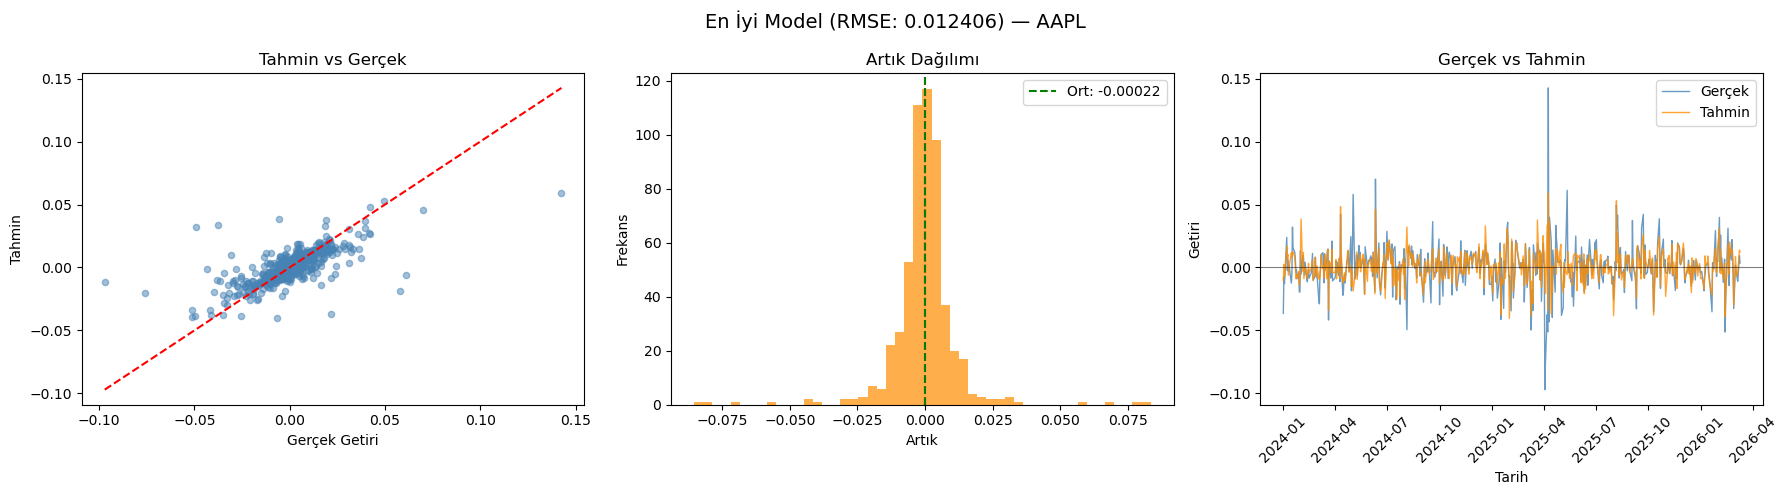

In [58]:
print(f"\n── EN İYİ MODEL (RMSE) ──")
print(rf_df.loc[rf_df["RMSE"].idxmin()])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
residuals_rmse = best_y_test_rmse - best_y_pred_rmse

axes[0].scatter(best_y_test_rmse, best_y_pred_rmse, alpha=0.5, color="steelblue", s=20)
axes[0].plot([best_y_test_rmse.min(), best_y_test_rmse.max()],
             [best_y_test_rmse.min(), best_y_test_rmse.max()], 'r--', linewidth=1.5)
axes[0].set_xlabel("Gerçek Getiri")
axes[0].set_ylabel("Tahmin")
axes[0].set_title("Tahmin vs Gerçek")

axes[1].hist(residuals_rmse, bins=50, color="darkorange", alpha=0.7, edgecolor="none")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].axvline(residuals_rmse.mean(), color="green", linestyle="--", linewidth=1.5,
                label=f"Ort: {residuals_rmse.mean():.5f}")
axes[1].set_xlabel("Artık")
axes[1].set_ylabel("Frekans")
axes[1].set_title("Artık Dağılımı")
axes[1].legend()

axes[2].plot(best_dates_rmse, best_y_test_rmse, label="Gerçek", color="steelblue", linewidth=1, alpha=0.8)
axes[2].plot(best_dates_rmse, best_y_pred_rmse, label="Tahmin", color="darkorange", linewidth=1, alpha=0.8)
axes[2].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[2].set_xlabel("Tarih")
axes[2].set_ylabel("Getiri")
axes[2].set_title("Gerçek vs Tahmin")
axes[2].legend()
axes[2].tick_params(axis="x", rotation=45)

plt.suptitle(f"En İyi Model (RMSE: {best_rmse:.6f}) — {TICKER}", fontsize=14)
plt.tight_layout()
plt.show()


── EN İYİ MODEL (MAE) ──
model    ARMA(2,0)_ARCH(0)
RMSE              0.012406
MAE               0.006978
Name: 16, dtype: object


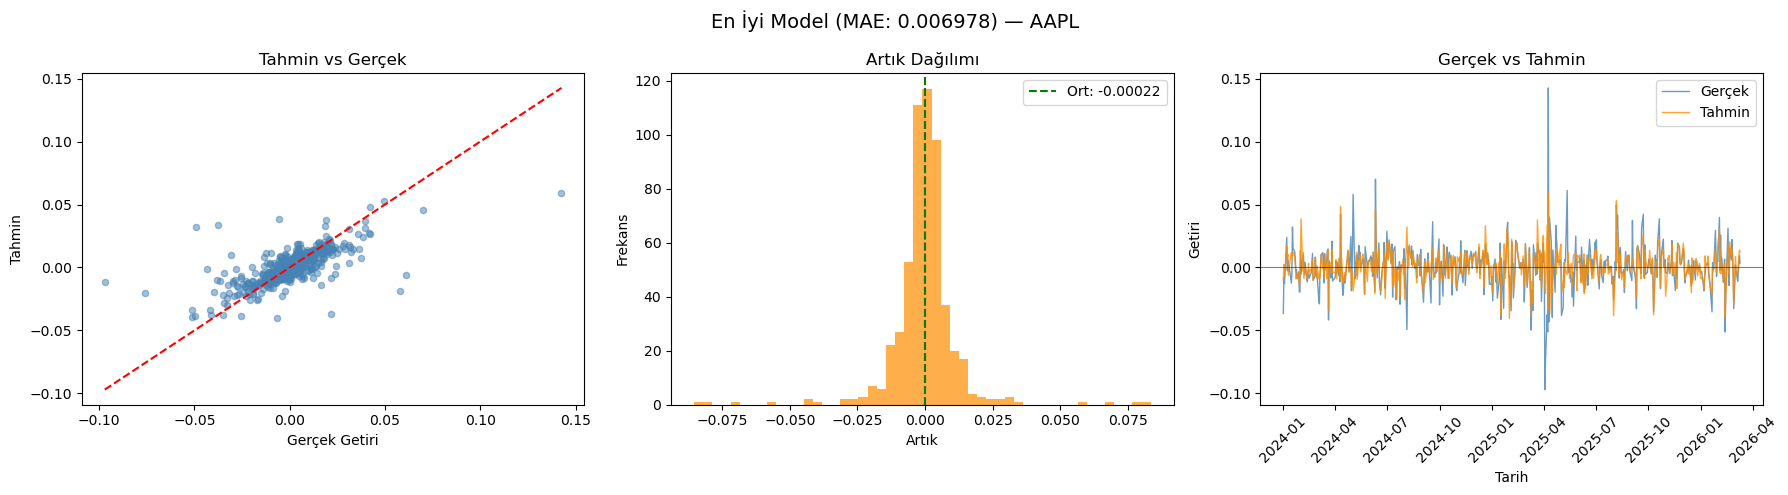

In [59]:
print(f"\n── EN İYİ MODEL (MAE) ──")
print(rf_df.loc[rf_df["MAE"].idxmin()])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
residuals_mae = best_y_test_mae - best_y_pred_mae

axes[0].scatter(best_y_test_mae, best_y_pred_mae, alpha=0.5, color="steelblue", s=20)
axes[0].plot([best_y_test_mae.min(), best_y_test_mae.max()],
             [best_y_test_mae.min(), best_y_test_mae.max()], 'r--', linewidth=1.5)
axes[0].set_xlabel("Gerçek Getiri")
axes[0].set_ylabel("Tahmin")
axes[0].set_title("Tahmin vs Gerçek")

axes[1].hist(residuals_mae, bins=50, color="darkorange", alpha=0.7, edgecolor="none")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].axvline(residuals_mae.mean(), color="green", linestyle="--", linewidth=1.5,
                label=f"Ort: {residuals_mae.mean():.5f}")
axes[1].set_xlabel("Artık")
axes[1].set_ylabel("Frekans")
axes[1].set_title("Artık Dağılımı")
axes[1].legend()

axes[2].plot(best_dates_mae, best_y_test_mae, label="Gerçek", color="steelblue", linewidth=1, alpha=0.8)
axes[2].plot(best_dates_mae, best_y_pred_mae, label="Tahmin", color="darkorange", linewidth=1, alpha=0.8)
axes[2].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[2].set_xlabel("Tarih")
axes[2].set_ylabel("Getiri")
axes[2].set_title("Gerçek vs Tahmin")
axes[2].legend()
axes[2].tick_params(axis="x", rotation=45)

plt.suptitle(f"En İyi Model (MAE: {best_mae:.6f}) — {TICKER}", fontsize=14)
plt.tight_layout()
plt.show()

In [60]:
xgb_results = []
best_rmse   = float("inf")
best_mae    = float("inf")
best_y_test_rmse = best_y_pred_rmse = best_dates_rmse = None
best_y_test_mae  = best_y_pred_mae  = best_dates_mae  = None

for p, q, r in product(P_RANGE, Q_RANGE, R_RANGE):
    try:
        lag_cols = []
        ar_df = ticker_df
        for i in range(1, p + 1):
            c = f"lag_{i}"
            ar_df = ar_df.withColumn(c, F.lag("return", i).over(w))
            lag_cols.append(c)
        ar_df = ar_df.dropna(subset=lag_cols)

        vec      = VectorAssembler(inputCols=lag_cols, outputCol="ar_features")
        ar_vec   = vec.transform(ar_df)
        lr       = LinearRegression(featuresCol="ar_features", labelCol="return", regParam=0.01, fitIntercept=False)
        lr_model = lr.fit(ar_vec)
        resid_df = lr_model.transform(ar_vec) \
            .withColumn("residual", F.col("return") - F.col("prediction")) \
            .drop("ar_features", "prediction")

        ma_cols = []
        if q > 0:
            for i in range(1, q + 1):
                c = f"eps_{i}"
                resid_df = resid_df.withColumn(c, F.lag("residual", i).over(w))
                ma_cols.append(c)
            resid_df = resid_df.dropna(subset=ma_cols)

        arch_cols = []
        if r > 0:
            for i in range(1, r + 1):
                c = f"eps2_{i}"
                resid_df = resid_df.withColumn(c, F.pow(F.lag("residual", i).over(w), 2))
                arch_cols.append(c)
            resid_df = resid_df.dropna(subset=arch_cols)

        feature_cols = BASE_FEATURES + lag_cols + ma_cols + arch_cols
        pdf      = resid_df.orderBy("date").select(feature_cols + ["return", "date"]).toPandas()
        train_pd = pdf[pdf["date"] < SPLIT]
        test_pd  = pdf[pdf["date"] >= SPLIT]

        if len(train_pd) < 50 or len(test_pd) < 20:
            continue

        X_train = train_pd[feature_cols].astype(np.float32).values
        y_train = train_pd["return"].astype(np.float32).values
        X_test  = test_pd[feature_cols].astype(np.float32).values
        y_test  = test_pd["return"].astype(np.float32).values

        model = xgb.XGBRegressor(
            n_estimators=100, max_depth=5,
            device="cuda", random_state=42,
            verbosity=0
        )
        model.fit(X_train, y_train)
        y_pred = np.array(model.predict(X_test))

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae  = mean_absolute_error(y_test, y_pred)

        xgb_results.append({
            "model": f"ARMA({p},{q})_ARCH({r})",
            "RMSE" : round(float(rmse), 6),
            "MAE"  : round(float(mae), 6),
        })

        if rmse < best_rmse:
            best_rmse        = rmse
            best_y_test_rmse = y_test.copy()
            best_y_pred_rmse = y_pred.copy()
            best_dates_rmse  = test_pd["date"].values.copy()

        if mae < best_mae:
            best_mae        = mae
            best_y_test_mae = y_test.copy()
            best_y_pred_mae = y_pred.copy()
            best_dates_mae  = test_pd["date"].values.copy()

    except Exception as e:
        print(f"HATA: ARMA({p},{q}) ARCH({r}) → {e}")

xgb_df = pd.DataFrame(xgb_results)


── EN İYİ MODEL (RMSE) ──
model    ARMA(3,2)_ARCH(3)
RMSE              0.013798
MAE               0.007998
Name: 43, dtype: object


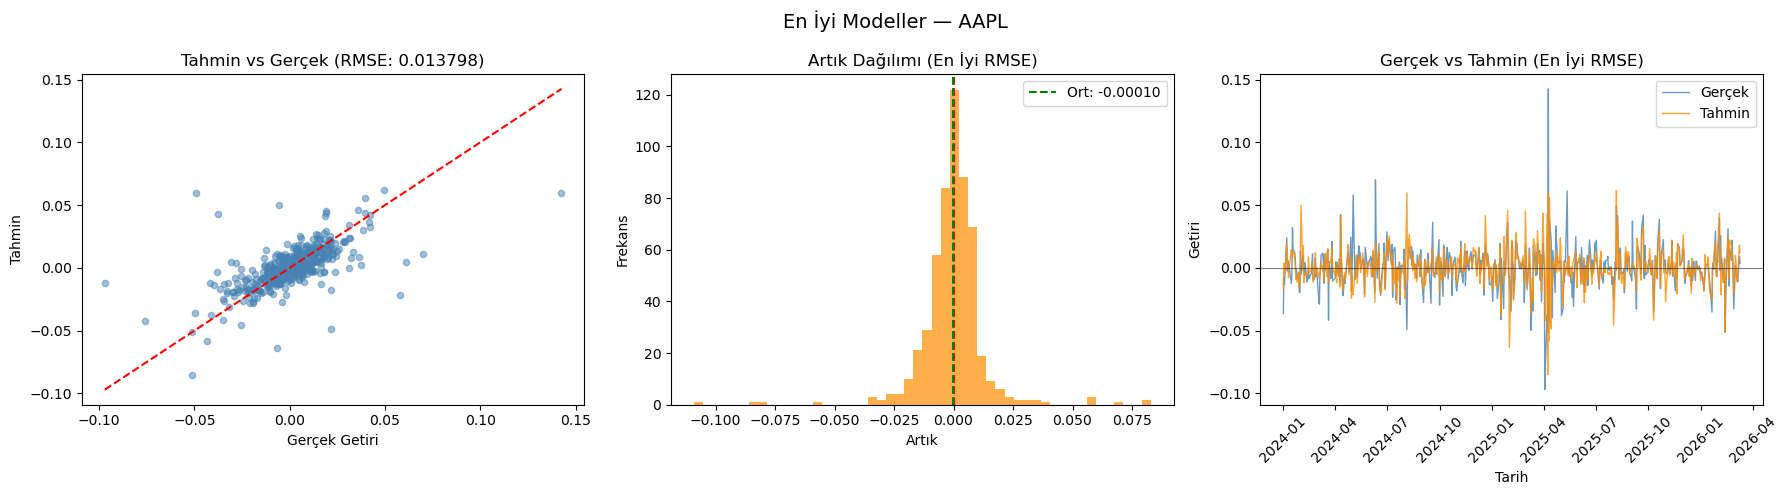

In [61]:
print(f"\n── EN İYİ MODEL (RMSE) ──")
print(xgb_df.loc[xgb_df["RMSE"].idxmin()])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

residuals_rmse = best_y_test_rmse - best_y_pred_rmse

axes[0].scatter(best_y_test_rmse, best_y_pred_rmse, alpha=0.5, color="steelblue", s=20)
axes[0].plot([best_y_test_rmse.min(), best_y_test_rmse.max()],
                [best_y_test_rmse.min(), best_y_test_rmse.max()], 'r--', linewidth=1.5)
axes[0].set_xlabel("Gerçek Getiri")
axes[0].set_ylabel("Tahmin")
axes[0].set_title(f"Tahmin vs Gerçek (RMSE: {best_rmse:.6f})")

axes[1].hist(residuals_rmse, bins=50, color="darkorange", alpha=0.7, edgecolor="none")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].axvline(residuals_rmse.mean(), color="green", linestyle="--", linewidth=1.5,
                   label=f"Ort: {residuals_rmse.mean():.5f}")
axes[1].set_xlabel("Artık")
axes[1].set_ylabel("Frekans")
axes[1].set_title("Artık Dağılımı (En İyi RMSE)")
axes[1].legend()

axes[2].plot(best_dates_rmse, best_y_test_rmse, label="Gerçek", color="steelblue", linewidth=1, alpha=0.8)
axes[2].plot(best_dates_rmse, best_y_pred_rmse, label="Tahmin", color="darkorange", linewidth=1, alpha=0.8)
axes[2].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[2].set_xlabel("Tarih")
axes[2].set_ylabel("Getiri")
axes[2].set_title("Gerçek vs Tahmin (En İyi RMSE)")
axes[2].legend()
axes[2].tick_params(axis="x", rotation=45)

plt.suptitle(f"En İyi Modeller — {TICKER}", fontsize=14)
plt.tight_layout()
plt.show()


── EN İYİ MODEL (MAE) ──
model    ARMA(2,1)_ARCH(0)
RMSE              0.014251
MAE                0.00766
Name: 20, dtype: object


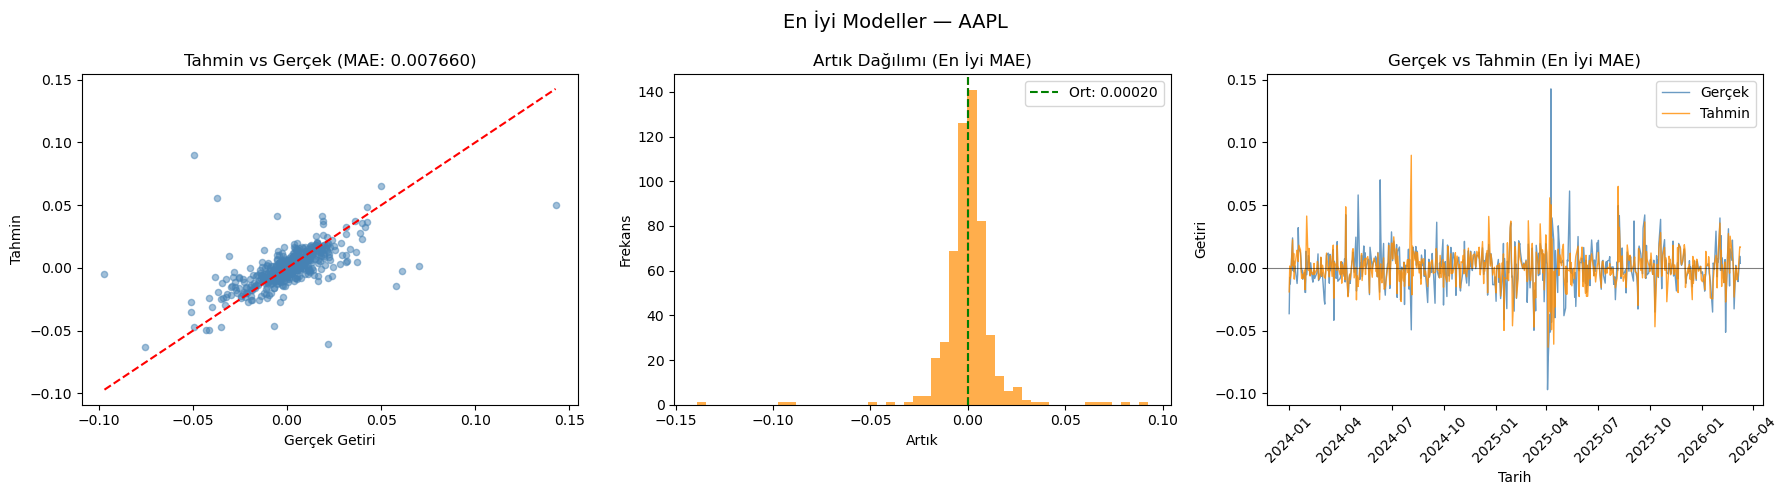

In [62]:
print(f"\n── EN İYİ MODEL (MAE) ──")
print(xgb_df.loc[xgb_df["MAE"].idxmin()])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

residuals_mae = best_y_test_mae - best_y_pred_mae

axes[0].scatter(best_y_test_mae, best_y_pred_mae, alpha=0.5, color="steelblue", s=20)
axes[0].plot([best_y_test_mae.min(), best_y_test_mae.max()],
                [best_y_test_mae.min(), best_y_test_mae.max()], 'r--', linewidth=1.5)
axes[0].set_xlabel("Gerçek Getiri")
axes[0].set_ylabel("Tahmin")
axes[0].set_title(f"Tahmin vs Gerçek (MAE: {best_mae:.6f})")

axes[1].hist(residuals_mae, bins=50, color="darkorange", alpha=0.7, edgecolor="none")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].axvline(residuals_mae.mean(), color="green", linestyle="--", linewidth=1.5,
                   label=f"Ort: {residuals_mae.mean():.5f}")
axes[1].set_xlabel("Artık")
axes[1].set_ylabel("Frekans")
axes[1].set_title("Artık Dağılımı (En İyi MAE)")
axes[1].legend()

axes[2].plot(best_dates_mae, best_y_test_mae, label="Gerçek", color="steelblue", linewidth=1, alpha=0.8)
axes[2].plot(best_dates_mae, best_y_pred_mae, label="Tahmin", color="darkorange", linewidth=1, alpha=0.8)
axes[2].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[2].set_xlabel("Tarih")
axes[2].set_ylabel("Getiri")
axes[2].set_title("Gerçek vs Tahmin (En İyi MAE)")
axes[2].legend()
axes[2].tick_params(axis="x", rotation=45)

plt.suptitle(f"En İyi Modeller — {TICKER}", fontsize=14)
plt.tight_layout()
plt.show()

# Monte Carlo

In [26]:
import warnings
warnings.filterwarnings("ignore")

import cupy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

returns_pivot = returns_indices \
    .groupBy("date") \
    .pivot("ticker") \
    .agg(F.first("return")) \
    .orderBy("date") \
    .dropna() \
    .toPandas()

returns_pivot = returns_pivot.set_index("date")
returns_pivot.index = pd.to_datetime(returns_pivot.index)
tickers = returns_pivot.columns.tolist()

mu_hist    = returns_pivot.mean().values
sigma_hist = returns_pivot.cov().values
skew_hist  = returns_pivot.skew().values
kurt_hist  = returns_pivot.kurtosis().values
mu_current = returns_pivot.tail(60).mean().values

n_sim  = 100_000
n_days = 252

=== TARİHSEL MOMENTLER ===
        μ (tüm)  μ (son 60)       σ  Çarpıklık  Basıklık
DJI      0.0003     -0.0001  0.0126    -0.8480   21.8407
NASDAQ   0.0006     -0.0007  0.0158    -0.4098    7.9286
SP500    0.0005     -0.0003  0.0131    -0.6443   14.8739

=== MAKSİMUM KAYIP SİMÜLASYONU (252 Gün, 100,000 Senaryo) ===
        Ort. Yıllık Getiri  Ort. Max DD  Max DD VaR %5  Max DD VaR %1  \
DJI                -0.0343      -0.4066        -0.7069        -0.8244   
NASDAQ             -0.1636      -0.4787        -0.7668        -0.8670   
SP500              -0.0669      -0.4173        -0.7111        -0.8244   

        Medyan Max DD  En Kötü DD  P(DD > %20)  P(DD > %30)  P(DD > %40)  
DJI           -0.3879     -2.0470       0.9035       0.6987       0.4736  
NASDAQ        -0.4688     -2.0011       0.9689       0.8404       0.6444  
SP500         -0.4004     -1.9675       0.9220       0.7263       0.5010  


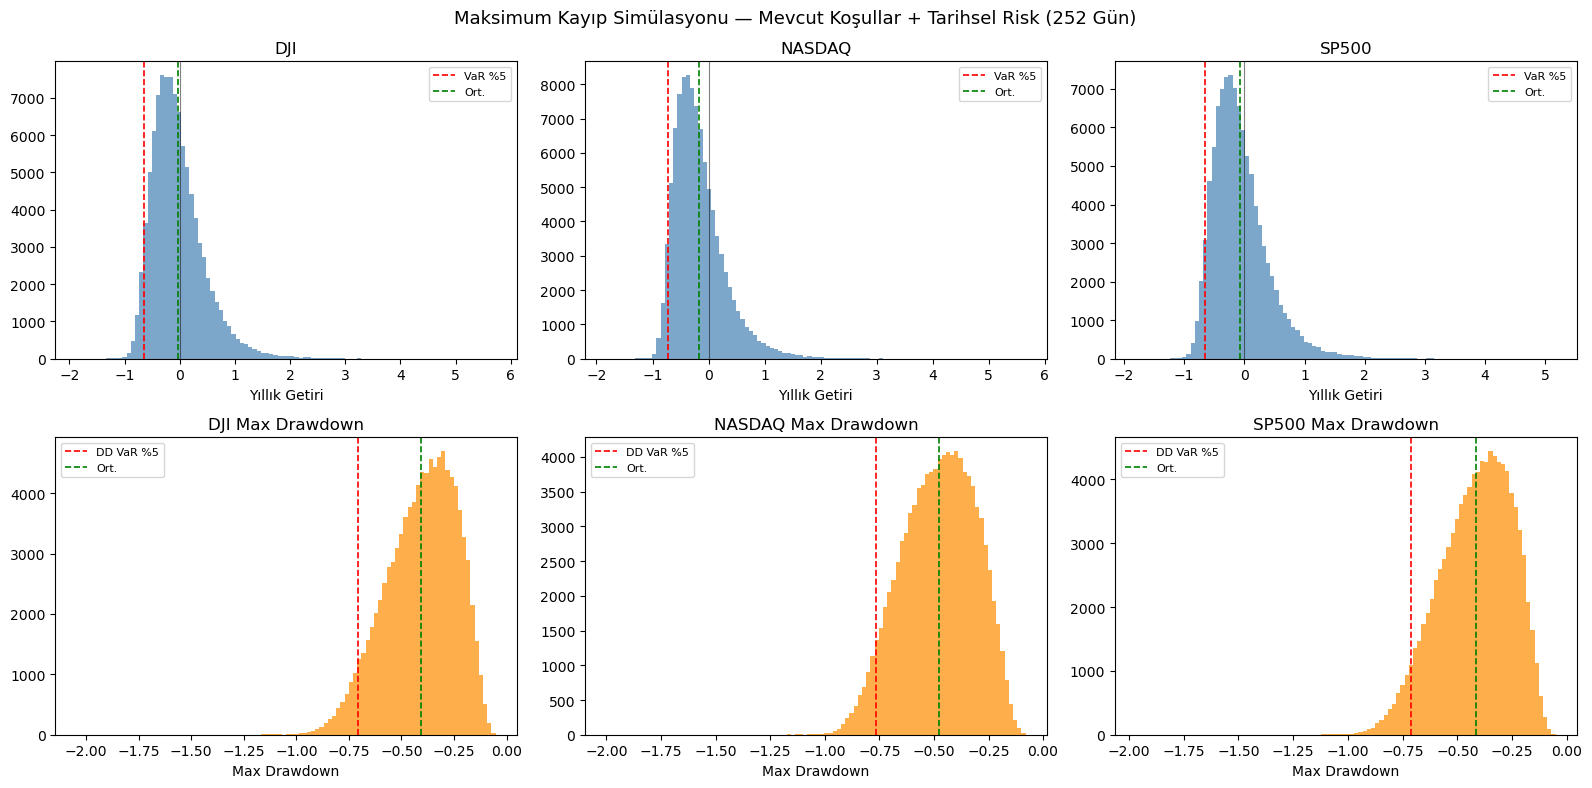

In [66]:
warnings.filterwarnings("ignore")

print("=== TARİHSEL MOMENTLER ===")
pd.DataFrame({
    "μ (tüm)"    : mu_hist,
    "μ (son 60)" : mu_current,
    "σ"          : np.sqrt(np.diag(sigma_hist)),
    "Çarpıklık"  : skew_hist,
    "Basıklık"   : kurt_hist
}, index=tickers).round(4).pipe(print)


mu_gpu    = cp.array(mu_current, dtype=cp.float32)
sigma_gpu = cp.array(sigma_hist, dtype=cp.float32)
skew_gpu  = cp.array(skew_hist, dtype=cp.float32)
kurt_gpu  = cp.array(kurt_hist, dtype=cp.float32)

L = cp.linalg.cholesky(sigma_gpu)

cp.random.seed(42)
Z = cp.random.standard_normal((n_sim, n_days, len(tickers))).astype(cp.float32)


Z_cf = (Z
    + (Z**2 - 1) * skew_gpu / 6
    + (Z**3 - 3*Z) * kurt_gpu / 24
    - (2*Z**3 - 5*Z) * skew_gpu**2 / 36
)

# Korelasyonlu getiriler
sim_returns = cp.zeros((n_sim, n_days, len(tickers)), dtype=cp.float32)
for d in range(n_days):
    sim_returns[:, d, :] = mu_gpu + (L @ Z_cf[:, d, :].T).T


cum_paths    = cp.cumprod(1 + sim_returns, axis=1)
cum_paths_np = cp.asnumpy(cum_paths)


running_max = np.maximum.accumulate(cum_paths_np, axis=1)
drawdowns   = (cum_paths_np - running_max) / running_max
max_dd_np   = np.min(drawdowns, axis=1)  # (n_sim, n_tickers)


annual_returns_np = cum_paths_np[:, -1, :] - 1

cum_df = pd.DataFrame(annual_returns_np, columns=tickers)
dd_df  = pd.DataFrame(max_dd_np, columns=tickers)


print("\n=== MAKSİMUM KAYIP SİMÜLASYONU (252 Gün, 100,000 Senaryo) ===")
summary = pd.DataFrame({
    "Ort. Yıllık Getiri" : cum_df.mean(),
    "Ort. Max DD"        : dd_df.mean(),
    "Max DD VaR %5"      : dd_df.quantile(0.05),
    "Max DD VaR %1"      : dd_df.quantile(0.01),
    "Medyan Max DD"      : dd_df.median(),
    "En Kötü DD"         : dd_df.min(),
    "P(DD > %20)"        : (dd_df < -0.20).mean(),
    "P(DD > %30)"        : (dd_df < -0.30).mean(),
    "P(DD > %40)"        : (dd_df < -0.40).mean(),
}).round(4)
print(summary)


fig, axes = plt.subplots(2, len(tickers), figsize=(16, 8))

for j, ticker in enumerate(tickers):
    axes[0][j].hist(cum_df[ticker], bins=100, color="steelblue", alpha=0.7, edgecolor="none")
    axes[0][j].axvline(cum_df[ticker].quantile(0.05), color="red", linestyle="--", linewidth=1.2, label="VaR %5")
    axes[0][j].axvline(cum_df[ticker].mean(), color="green", linestyle="--", linewidth=1.2, label="Ort.")
    axes[0][j].axvline(0, color="black", linewidth=0.8, alpha=0.5)
    axes[0][j].set_title(ticker, fontsize=12)
    axes[0][j].set_xlabel("Yıllık Getiri")
    axes[0][j].legend(fontsize=8)

    axes[1][j].hist(dd_df[ticker], bins=100, color="darkorange", alpha=0.7, edgecolor="none")
    axes[1][j].axvline(dd_df[ticker].quantile(0.05), color="red", linestyle="--", linewidth=1.2, label="DD VaR %5")
    axes[1][j].axvline(dd_df[ticker].mean(), color="green", linestyle="--", linewidth=1.2, label="Ort.")
    axes[1][j].set_title(f"{ticker} Max Drawdown", fontsize=12)
    axes[1][j].set_xlabel("Max Drawdown")
    axes[1][j].legend(fontsize=8)

plt.suptitle("Maksimum Kayıp Simülasyonu — Mevcut Koşullar + Tarihsel Risk (252 Gün)", fontsize=13)
plt.tight_layout()
plt.show()

=== GERÇEK VaR DEĞERLERİ (Son 60 Gün) ===
DJI: VaR %5 = -0.0136, VaR %1 = -0.0172
NASDAQ: VaR %5 = -0.0171, VaR %1 = -0.0220
SP500: VaR %5 = -0.0124, VaR %1 = -0.0179

=== GERÇEK VaR SİMÜLASYONDA GERÇEKLEŞME OLASILIĞI ===

── Tam Tablo ──
Endeks    VaR  Gerçek VaR Değeri  Aşılan Nokta Gerçekleşme Olas. Beklenen Sıklık
   DJI var_95            -0.0136       1440694             5.72%            1/17
   DJI var_99            -0.0172       1299575             5.16%            1/19
NASDAQ var_95            -0.0171       2465978             9.79%            1/10
NASDAQ var_99            -0.0220       1939628              7.7%            1/13
 SP500 var_95            -0.0124       2537361            10.07%            1/10
 SP500 var_99            -0.0179       1691930             6.71%            1/15

=== SABİT KAYIP EŞİKLERİ İÇİN GERÇEKLEŞME OLASILIĞI ===

── Tam Tablo ──
Endeks Kayıp Eşiği  Aşılan Senaryo Gerçekleşme Olas. Beklenen Sıklık
   DJI         %10           51538            51.54

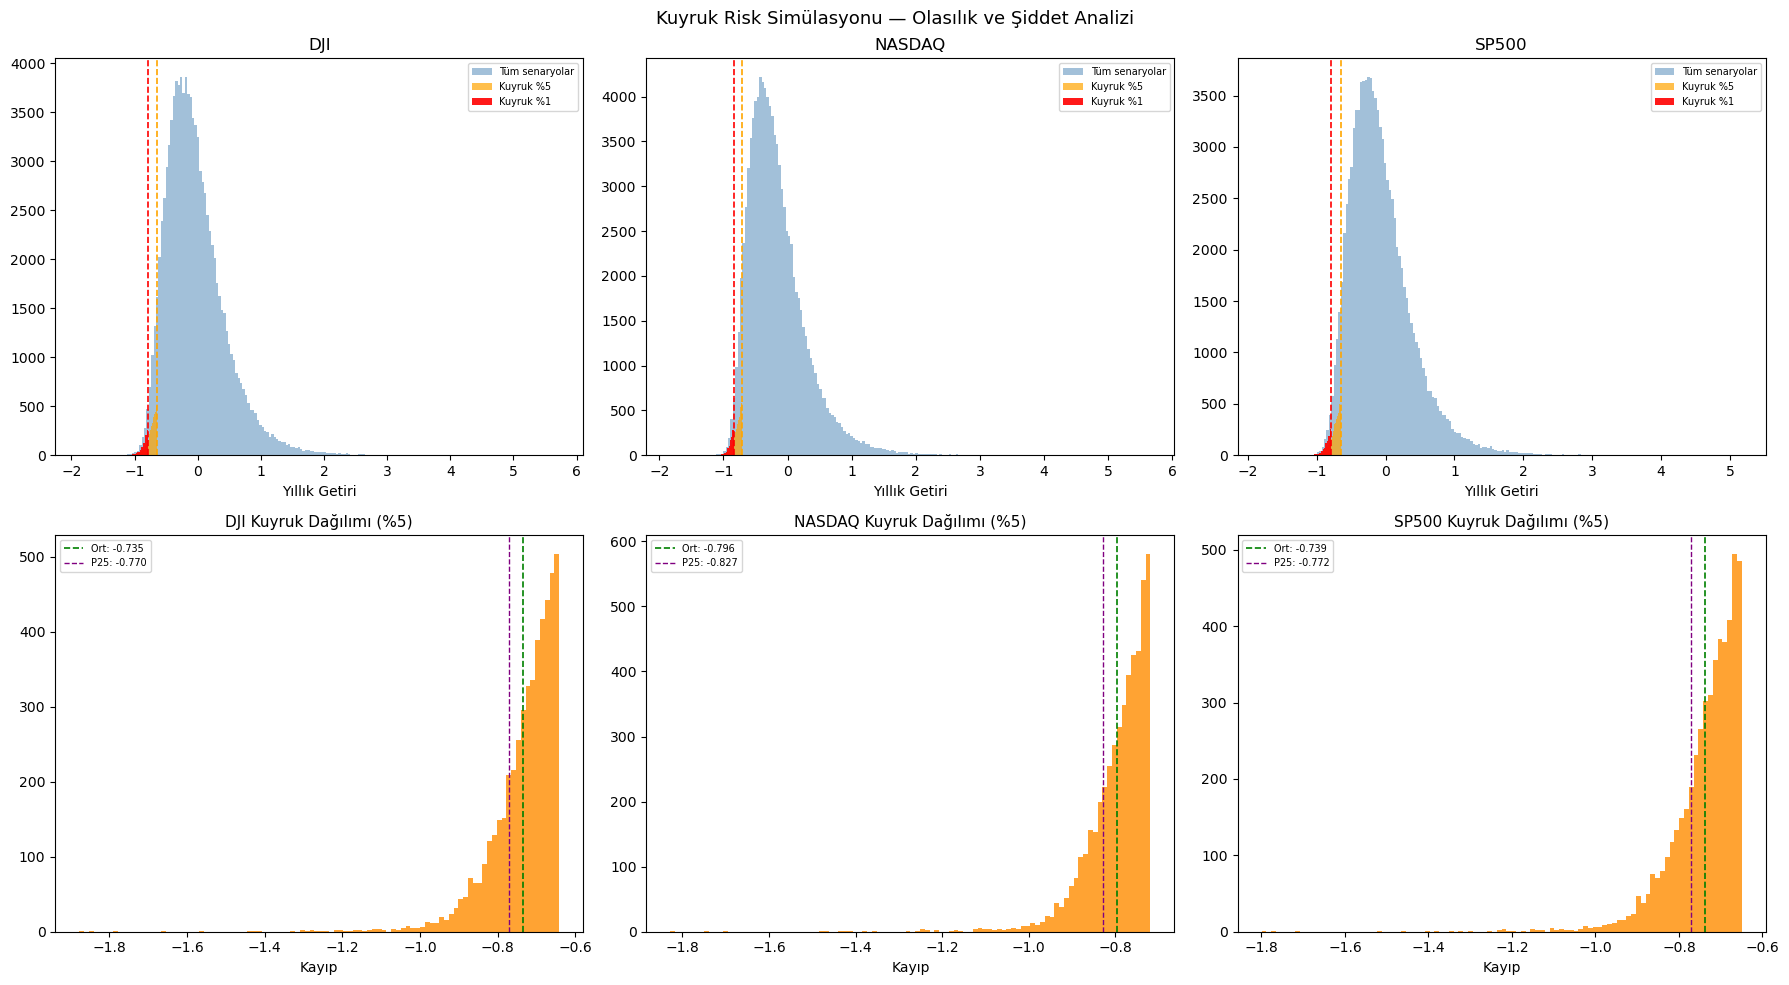

In [67]:
warnings.filterwarnings("ignore")


mu_gpu    = cp.array(mu_current, dtype=cp.float32)
sigma_gpu = cp.array(sigma_hist, dtype=cp.float32)
skew_gpu  = cp.array(skew_hist, dtype=cp.float32)
kurt_gpu  = cp.array(kurt_hist, dtype=cp.float32)
L         = cp.linalg.cholesky(sigma_gpu)

cp.random.seed(42)
Z    = cp.random.standard_normal((n_sim, n_days, len(tickers))).astype(cp.float32)
Z_cf = (Z
    + (Z**2 - 1) * skew_gpu / 6
    + (Z**3 - 3*Z) * kurt_gpu / 24
    - (2*Z**3 - 5*Z) * skew_gpu**2 / 36
)

sim_returns = cp.zeros((n_sim, n_days, len(tickers)), dtype=cp.float32)
for d in range(n_days):
    sim_returns[:, d, :] = mu_gpu + (L @ Z_cf[:, d, :].T).T

cum_paths    = cp.cumprod(1 + sim_returns, axis=1)
cum_paths_np = cp.asnumpy(cum_paths)
annual_ret   = cum_paths_np[:, -1, :] - 1
cum_df       = pd.DataFrame(annual_ret, columns=tickers)


print("=== GERÇEK VaR DEĞERLERİ (Son 60 Gün) ===")
current_data = returns_pivot.tail(60)
real_var = {}
for ticker in tickers:
    var_95 = current_data[ticker].quantile(0.05)
    var_99 = current_data[ticker].quantile(0.01)
    real_var[ticker] = {"var_95": var_95, "var_99": var_99}
    print(f"{ticker}: VaR %5 = {var_95:.4f}, VaR %1 = {var_99:.4f}")


print("\n=== GERÇEK VaR SİMÜLASYONDA GERÇEKLEŞME OLASILIĞI ===")
real_var_rows = []
for ticker_idx, ticker in enumerate(tickers):
    daily_rets_np = sim_returns[:, :, ticker_idx].reshape(-1)
    if hasattr(daily_rets_np, 'get'):
        daily_rets_np = daily_rets_np.get()
    for var_name, var_val in real_var[ticker].items():
        n_breach = (daily_rets_np < var_val).sum()
        p_breach = n_breach / len(daily_rets_np)
        real_var_rows.append({
            "Endeks"            : ticker,
            "VaR"               : var_name,
            "Gerçek VaR Değeri" : round(float(var_val), 4),
            "Aşılan Nokta"      : int(n_breach),
            "Gerçekleşme Olas." : f"{round(float(p_breach)*100, 2)}%",
            "Beklenen Sıklık"   : f"1/{int(round(1/p_breach)) if p_breach > 0 else '∞'}"
        })

real_var_df = pd.DataFrame(real_var_rows)
print("\n── Tam Tablo ──")
print(real_var_df.to_string(index=False))


fixed_thresholds = [-0.10, -0.20, -0.30, -0.40, -0.50]
print("\n=== SABİT KAYIP EŞİKLERİ İÇİN GERÇEKLEŞME OLASILIĞI ===")
var_prob_rows = []
for ticker_idx, ticker in enumerate(tickers):
    ret_series = annual_ret[:, ticker_idx]
    for thresh in fixed_thresholds:
        n_breach = (ret_series < thresh).sum()
        p_breach = n_breach / n_sim
        var_prob_rows.append({
            "Endeks"            : ticker,
            "Kayıp Eşiği"       : f"%{abs(thresh)*100:.0f}",
            "Aşılan Senaryo"    : int(n_breach),
            "Gerçekleşme Olas." : f"{round(p_breach*100, 2)}%",
            "Beklenen Sıklık"   : f"1/{int(round(1/p_breach)) if p_breach > 0 else '∞'}"
        })

var_prob_df = pd.DataFrame(var_prob_rows)
print("\n── Tam Tablo ──")
print(var_prob_df.to_string(index=False))


thresholds = [0.05, 0.01, 0.001]
print("\n=== KUYRUK RİSK SİMÜLASYONU ===\n")

tail_results = []
for ticker_idx, ticker in enumerate(tickers):
    ret_series = cum_df[ticker]
    print(f"── {ticker} ──")

    for thresh in thresholds:
        var_level = ret_series.quantile(thresh)
        tail_mask = ret_series < var_level
        tail_rets = ret_series[tail_mask]
        n_tail    = tail_mask.sum()

        tail_mean = tail_rets.mean()
        tail_std  = tail_rets.std()
        tail_min  = tail_rets.min()

        print(f"  VaR %{thresh*100:.1f} eşiği: {var_level:.4f}")
        print(f"  Senaryo sayısı   : {n_tail} ({thresh*100:.1f}%)")
        print(f"  Kuyruk ortalaması: {tail_mean:.4f}")
        print(f"  Kuyruk std       : {tail_std:.4f}")
        print(f"  En kötü          : {tail_min:.4f}")
        print()

        tail_results.append({
            "Endeks"    : ticker,
            "Eşik"      : f"%{thresh*100:.1f}",
            "VaR"       : round(var_level, 4),
            "Ort. Kayıp": round(tail_mean, 4),
            "Std"       : round(tail_std, 4),
            "En Kötü"   : round(tail_min, 4)
        })


print("=== KUYRUK YAYILIMI (Kuyruk Olayı Gerçekleşirse Sonraki 20 Gün) ===\n")

for ticker_idx, ticker in enumerate(tickers):
    var_5      = cum_df[ticker].quantile(0.05)
    tail_idx   = np.where(annual_ret[:, ticker_idx] < var_5)[0]
    tail_paths = cum_paths_np[tail_idx, :, ticker_idx]

    running_max = np.maximum.accumulate(tail_paths, axis=1)
    dd_paths    = (tail_paths - running_max) / running_max
    worst_day   = np.argmin(dd_paths, axis=1)

    post_tail = []
    for i, wday in enumerate(worst_day):
        if wday + 20 < n_days:
            start_val = tail_paths[i, wday]
            post_path = tail_paths[i, wday:wday+20] / start_val - 1
            post_tail.append(post_path)

    if len(post_tail) > 0:
        post_arr  = np.array(post_tail)
        mean_path = post_arr.mean(axis=0)
        p5_path   = np.percentile(post_arr, 5, axis=0)
        p95_path  = np.percentile(post_arr, 95, axis=0)

        print(f"{ticker} — Kuyruk sonrası 20 gün:")
        print(f"  Ortalama toparlanma : {mean_path[-1]:.4f}")
        print(f"  %5 senaryo          : {p5_path[-1]:.4f}")
        print(f"  %95 senaryo         : {p95_path[-1]:.4f}")


fig, axes = plt.subplots(2, len(tickers), figsize=(18, 10))

for j, ticker in enumerate(tickers):
    ret_series = cum_df[ticker]
    var_5  = ret_series.quantile(0.05)
    var_1  = ret_series.quantile(0.01)
    tail_5 = ret_series[ret_series < var_5]
    tail_1 = ret_series[ret_series < var_1]

    axes[0][j].hist(ret_series, bins=200, color="steelblue", alpha=0.5, edgecolor="none", label="Tüm senaryolar")
    axes[0][j].hist(tail_5, bins=100, color="orange", alpha=0.7, edgecolor="none", label="Kuyruk %5")
    axes[0][j].hist(tail_1, bins=50, color="red", alpha=0.9, edgecolor="none", label="Kuyruk %1")
    axes[0][j].axvline(var_5, color="orange", linestyle="--", linewidth=1.2)
    axes[0][j].axvline(var_1, color="red", linestyle="--", linewidth=1.2)
    axes[0][j].set_title(ticker, fontsize=12)
    axes[0][j].set_xlabel("Yıllık Getiri")
    axes[0][j].legend(fontsize=7)

    axes[1][j].hist(tail_5, bins=100, color="darkorange", alpha=0.8, edgecolor="none")
    axes[1][j].axvline(tail_5.mean(), color="green", linestyle="--", linewidth=1.2, label=f"Ort: {tail_5.mean():.3f}")
    axes[1][j].axvline(tail_5.quantile(0.25), color="purple", linestyle="--", linewidth=1, label=f"P25: {tail_5.quantile(0.25):.3f}")
    axes[1][j].set_title(f"{ticker} Kuyruk Dağılımı (%5)", fontsize=11)
    axes[1][j].set_xlabel("Kayıp")
    axes[1][j].legend(fontsize=7)

plt.suptitle("Kuyruk Risk Simülasyonu — Olasılık ve Şiddet Analizi", fontsize=13)
plt.tight_layout()
plt.show()

In [68]:
del Z, Z_cf, sim_returns, cum_paths
cp.get_default_memory_pool().free_all_blocks()
cp.get_default_pinned_memory_pool().free_all_blocks()

In [69]:
spark.stop()